<h1>Predicting and Analyzing Salaries</h1>

<h2>Load & Exlplore

In [1059]:
import pandas as pd
import numpy as np
import re

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', None)
np.set_printoptions(threshold=np.inf)

df_salary = pd.read_csv('Ask-A-Manager-Salary-Survey-2021-Responses-Form-Responses-1-hh5hef.csv')
print(df_salary.head())
print('\n--- Shape ---')
print(df_salary.shape)

# Quick profiling
print('\n--- Info ---')
print(df_salary.info())
print('\n--- Describe ---')
print(df_salary.describe(include='number'))

            Timestamp How old are you?  What industry do you work in?  \
0  4/27/2021 11:02:10            25-34   Education (Higher Education)   
1  4/27/2021 11:02:22            25-34              Computing or Tech   
2  4/27/2021 11:02:38            25-34  Accounting, Banking & Finance   
3  4/27/2021 11:02:41            25-34                     Nonprofits   
4  4/27/2021 11:02:42            25-34  Accounting, Banking & Finance   

                                  Job title  \
0        Research and Instruction Librarian   
1  Change & Internal Communications Manager   
2                      Marketing Specialist   
3                           Program Manager   
4                        Accounting Manager   

  If your job title needs additional context, please clarify here:  \
0                                                NaN                 
1                                                NaN                 
2                                                NaN                

<h2>Basic Cleaning</h2>

<h3>Renaming and Formatting Column Names</h3>

In [1062]:
column_rename_map = {
    'Timestamp': 'timestamp',
    'How old are you?': 'age',
    'What industry do you work in?': 'industry',
    'Job title': 'job_title',
    'If your job title needs additional context, please clarify here:': 'job_title_context',
    "What is your annual salary? (You'll indicate the currency in a later question. If you are part-time or hourly, please enter an annualized equivalent -- what you would earn if you worked the job 40 hours a week, 52 weeks a year.)": 'annual_salary',
    'How much additional monetary compensation do you get, if any (for example, bonuses or overtime in an average year)? Please only include monetary compensation here, not the value of benefits.': 'additional_compensation',
    'Please indicate the currency': 'currency',
    'If "Other," please indicate the currency here: ': 'currency_other',
    'If your income needs additional context, please provide it here:': 'income_context',
    'What country do you work in?': 'country',
    "If you're in the U.S., what state do you work in?": 'state',
    'What city do you work in?': 'city',
    'How many years of professional work experience do you have overall?': 'overall_experience_years',
    'How many years of professional work experience do you have in your field?': 'field_experience_years',
    'What is your highest level of education completed?': 'education_level',
    'What is your gender?': 'gender',
    'What is your race? (Choose all that apply.)': 'race'
}

df_salary = df_salary.rename(columns=column_rename_map)

<h3>Fixing Data Types</h3>

In [1064]:
df_salary['timestamp'] = pd.to_datetime(df_salary['timestamp'])

# 'age' Conversion
def calculate_age_midpoint(age_range):
    if isinstance(age_range, str) and '-' in age_range:
        try:
            low, high = age_range.split('-')
            return round((int(low) + int(high)) / 2)
        except ValueError:
            return np.nan
    else:
        try:
            return round(float(age_range))
        except ValueError:
            return np.nan

df_salary['age'] = df_salary['age'].apply(calculate_age_midpoint)

# 'annual_salary' Conversion
def fix_salary_format(unformed_salary):
    if unformed_salary.isdigit():
        try:
            return float(unformed_salary)
        except ValueError:
            return np.nan
    else:
        formatted_salary = re.sub(r'[^0-9]', '', unformed_salary)
        try:
            return int(formatted_salary)
        except ValueError:
            return np.nan
df_salary['annual_salary'] = df_salary['annual_salary'].apply(fix_salary_format)

# 'overall_experience_years' Conversion
def calculate_exp_years(raw_input):
    if not isinstance(raw_input, str):
        return np.nan
    elif '1 year or less' in raw_input.lower():
        return 1

    # Searchin for ranges
    match = re.search(r'(\d+)\s*[\-–]\s*(\d+)', raw_input)
    if match:
        try:
            num1 = int(match.group(1))
            num2 = int(match.group(2))
            exp_mean = round((num1 + num2) / 2)
            
            return exp_mean
            
        except ValueError:
            return np.nan
    else:
        # Finding this sort of matches: X years
        single_group_match = re.search(r'(\d+)\s*ye', raw_input)
        if single_group_match:
            try:
                return round(int(single_group_match.group(1)))
            except ValueError:
                return np.nan

        # Finding this sort of matches: X+ years
        plus_num_match = re.search(r'(\d+)\s*\+\s*ye')
        if plus_num_match:
            try:
                return round(int(plus_num_match.group(1)))
            except ValueError:
                return np.nan

        return np.nan
    
df_salary['overall_experience_years'] = df_salary['overall_experience_years'].apply(calculate_exp_years)

# We can use the 'calculate_exp_years' on 'field_experience_years' column as well
df_salary['field_experience_years'] = df_salary['field_experience_years'].apply(calculate_exp_years)

<h3>Let's deal with outliers</h3>

In [1066]:
low_quantile = 0.01
high_quantile = 0.99

df_salary_original = df_salary.copy()

target_cols = df_salary.select_dtypes(include=np.number).columns

outlier_bounds = {}

for col in target_cols:
    q_low = df_salary[col].quantile(low_quantile)
    q_high = df_salary[col].quantile(high_quantile)

    outlier_bounds = {'low': q_low, 'high': q_high}

    initial_rows = len(df_salary)
    df_salary = df_salary[
        (df_salary[col] >= q_low) &
        (df_salary[col] <= q_high)
    ]
    rows_removed = initial_rows - len(df_salary)

    if rows_removed > 0:
        print(f'- Removed {rows_removed} rows based on outliers in {col} (Original: {initial_rows}, New: {len(df_salary)})')
    else:
        print(f'- No outliers removed for {col} (Range: {q_low} to {q_high}')

print(f'\nFinished filtering the outliers. Final rows: {len(df_salary)}')
print(f'\nTotal rows removed: {len(df_salary_original) - len(df_salary)}')

- Removed 109 rows based on outliers in age (Original: 28151, New: 28042)
- Removed 562 rows based on outliers in annual_salary (Original: 28042, New: 27480)
- Removed 7324 rows based on outliers in additional_compensation (Original: 27480, New: 20156)
- Removed 68 rows based on outliers in overall_experience_years (Original: 20156, New: 20088)
- Removed 7 rows based on outliers in field_experience_years (Original: 20088, New: 20081)

Finished filtering the outliers. Final rows: 20081

Total rows removed: 8070


<h3>Remove Duplicates</h3>

<p>No duplicated rows so no need to drop anything</p>

<h3>Fill missing numerical values with median</h3>

In [1070]:
for col in ['age', 'annual_salary', 'additional_compensation', 'overall_experience_years', 'field_experience_years']:
    df_salary[col] = df_salary[col].fillna(df_salary[col].median())

<h3>Drop rows with essential missing categorical data</h3>

In [1072]:
df_salary.head()

,timestamp,age,industry,job_title,job_title_context,annual_salary,additional_compensation,currency,currency_other,income_context,country,state,city,overall_experience_years,field_experience_years,education_level,gender,race
0,2021-04-27 11:02:10,30.0,Education (Higher Education),Research and Instruction Librarian,NaN,55000.0,0.0,USD,NaN,NaN,United States,Massachusetts,Boston,6,6,Master's degree,Woman,White
1,2021-04-27 11:02:22,30.0,Computing or Tech,Change & Internal Communications Manager,NaN,54600.0,4000.0,GBP,NaN,NaN,United Kingdom,NaN,Cambridge,9,6,College degree,Non-binary,White
3,2021-04-27 11:02:41,30.0,Nonprofits,Program Manager,NaN,62000.0,3000.0,USD,NaN,NaN,USA,Wisconsin,Milwaukee,9,6,College degree,Woman,White
4,2021-04-27 11:02:42,30.0,"Accounting, Banking & Finance",Accounting Manager,NaN,60000.0,7000.0,USD,NaN,NaN,US,South Carolina,Greenville,9,6,College degree,Woman,White
6,2021-04-27 11:02:51,30.0,Publishing,Publishing Assistant,NaN,33000.0,2000.0,USD,NaN,NaN,USA,South Carolina,Columbia,3,3,College degree,Woman,White


<h2>Currency Normalization (quick heuristic)</h2>

In [1074]:
currency_map = {
    'USD': 1,
    'GBP': 1.27,
    'CAD': 0.74,
    'EUR': 1.08,
    'AUD/NZD': 0.65,
    'CHF': 1.10,
    'ZAR': 0.054,
    'HKD': 0.13,
    'JPY': 0.0067,
    'Other': 1.00
}

df_salary['salary_usd'] = df_salary.apply(
    lambda x: x['annual_salary'] * currency_map.get(x['currency'], 1), axis=1
)

df_salary['comp_usd'] = df_salary.apply(
    lambda x: x['additional_compensation'] * currency_map.get(x['currency'], 1), axis=1
)

def safe_to_float(val):
    try:
        return float(val)
    except (TypeError, ValueError):
        return 0

df_salary.head()

,timestamp,age,industry,job_title,job_title_context,annual_salary,additional_compensation,currency,currency_other,income_context,country,state,city,overall_experience_years,field_experience_years,education_level,gender,race,salary_usd,comp_usd
0,2021-04-27 11:02:10,30.0,Education (Higher Education),Research and Instruction Librarian,NaN,55000.0,0.0,USD,NaN,NaN,United States,Massachusetts,Boston,6,6,Master's degree,Woman,White,55000.0,0.0
1,2021-04-27 11:02:22,30.0,Computing or Tech,Change & Internal Communications Manager,NaN,54600.0,4000.0,GBP,NaN,NaN,United Kingdom,NaN,Cambridge,9,6,College degree,Non-binary,White,69342.0,5080.0
3,2021-04-27 11:02:41,30.0,Nonprofits,Program Manager,NaN,62000.0,3000.0,USD,NaN,NaN,USA,Wisconsin,Milwaukee,9,6,College degree,Woman,White,62000.0,3000.0
4,2021-04-27 11:02:42,30.0,"Accounting, Banking & Finance",Accounting Manager,NaN,60000.0,7000.0,USD,NaN,NaN,US,South Carolina,Greenville,9,6,College degree,Woman,White,60000.0,7000.0
6,2021-04-27 11:02:51,30.0,Publishing,Publishing Assistant,NaN,33000.0,2000.0,USD,NaN,NaN,USA,South Carolina,Columbia,3,3,College degree,Woman,White,33000.0,2000.0


<h3>Fixing Categorical Values</h3>

<h4>Let's fix the 'country' column</h4>

In [1077]:
def country_fix(country):
    if not isinstance(country, str):
        return 'Other'
    
    country = country.lower().strip()
    
    country_mapping = [
        # 🇺🇸 United States
        ("United States", [
            "united states", "united states ", "united states of america", 
            "united state of america", "united states of american", "united stares", 
            "united statesp", "united statss", "united states of america ", 
            "united states of american ", "united statws", "united stattes", 
            "united states ", "united state", "unites states", "unites states ", 
            "untied states", "unitied states", "uniited states", "us", "us ", "u.s.", 
            "u.s", "u s", "u.s ", "u.s>", "u.s.a", "u.s.a.", "u.s.a ", "usa", "usa ", 
            "u.s.a.", "uniter statez", "usaa", "usa tomorrow", "usab", "u.a.", "u. s.", 
            "u. s. ", "america", "the us", "the united states", "the u.s.", "u.s.", 
            "usd", "united states of american", "united states of america", 
            "united stares ", "united states of american", "united stated", 
            "united stares", "united states", "united sates", "united statss", 
            "united sttes", "united stares", "united states", "united states of america",
            "🇺🇸", "i work for a uae-based organization, though i am personally in the us."
        ]),
    
        # 🇬🇧 United Kingdom
        ("United Kingdom", [
            "united kingdom", "united kingdom ", "united kingdom.", 
            "uk", "uk ", "u.k.", "u.k", "u.k ", "uk (england)", "uk, remote",
            "great britain", "great britain ", "britain", "britain ",
            "england", "england ", "england, uk", "england, gb", "englang",
            "scotland", "scotland ", "wales", "wales (united kingdom)",
            "northern ireland", "northern ireland ", "northern ireland, united kingdom",
            "united kingdom (england)", "united kingdom.", "united kingom",
            "united kindom", "unites kingdom ", "england, united kingdom", 
            "uk, but for globally fully remote company", "scotland, uk", "wales, uk"
        ]),
    
        # 🇨🇦 Canada
        ("Canada", [
            "canada", "canada ", "canad", "canadw", "canda", "csnada", 
            "canada, ottawa, ontario", "i am located in canada but i work for a company in the us",
            "canadá"
        ]),
    
        # 🇦🇺 Australia
        ("Australia", [
            "australia", "australia ", "australi", "australi ", "australian "
        ]),
    
        # 🇳🇱 Netherlands
        ("Netherlands", [
            "the netherlands", "the netherlands ", "netherlands", "netherlands ", 
            "nl", "nederland", "the netherlands", "the netherlands", "the netherlands",
            "the netherlands", "the netherlands"
        ]),
    
        # 🇮🇪 Ireland
        ("Ireland", [
            "ireland", "ireland ", "northern ireland", "northern ireland "
        ]),
    
        # 🇫🇷 France
        ("France", [
            "france"
        ]),
        
        # 🇩🇪 Germany
        ("Germany", [
            "germany", "germany ", "german"
        ]),
    
        # 🇪🇸 Spain
        ("Spain", [
            "spain", "spain "
        ]),
        
        # 🇮🇹 Italy
        ("Italy", [
            "italy"
        ]),
    
        # 🇨🇭 Switzerland
        ("Switzerland", [
            "switzerland", "switzerland "
        ]),
    
        # 🇸🇪 Sweden
        ("Sweden", [
            "sweden"
        ]),
    
        # 🇧🇪 Belgium
        ("Belgium", [
            "belgium", "belgium "
        ]),
        
        # 🇦🇹 Austria
        ("Austria", [
            "austria"
        ]),
    
        # 🇧🇷 Brazil
        ("Brazil", [
            "brazil", "brasil"
        ]),
    
        # 🇵🇹 Portugal
        ("Portugal", [
            "portugal", "portugal "
        ]),
    
        # 🇭🇷 Croatia
        ("Croatia", [
            "croatia", "croatia ", "croatia"
        ]),
    
        # 🇱🇺 Luxembourg
        ("Luxembourg", [
            "luxembourg", "luxemburg"
        ]),
        
        # 🇰🇷 South Korea
        ("South Korea", [
            "south korea", "south korea "
        ]),
        
        # 🇯🇵 Japan
        ("Japan", [
            "japan", "japan, us gov position"
        ]),
        
        # 🇵🇰 Pakistan
        ("Pakistan", [
            "pakistan"
        ]),
    
        # 🇹🇭 Thailand
        ("Thailand", [
            "thailand", "thailand "
        ]),
        
        # 🇸🇦 Saudi Arabia
        ("Saudi Arabia", [
            "saudi arabia"
        ]),
        
        # 🇰🇪 Kenya
        ("Kenya", [
            "kenya"
        ]),
        
        # 🇳🇬 Nigeria
        ("Nigeria", [
            "nigeria", "nigeria "
        ]),
        
        # 🇺🇦 Ukraine
        ("Ukraine", [
            "ua"
        ]),
        
        # 🇱🇮 Liberia
        ("Liberia", [
            "liberia"
        ]),
        
        # 🇨🇴 Colombia
        ("Colombia", [
            "colombia"
        ]),
        
        # 🇸🇮 Slovenia
        ("Slovenia", [
            "slovenia"
        ]),
        
        # 🇩🇰 Denmark
        ("Denmark", [
            "denmark"
        ]),
    ]

    for country_key, countries in country_mapping:
        for country_check in countries:
            if country_check in country:
                return country_key

    return 'Other'

df_salary['country'] = df_salary['country'].apply(country_fix)

<h4>Now let's fix the 'state' column values</h4>

In [1079]:
def state_fix(state):
    if not isinstance(state, str):
        return 'Other'
    
    state = state.lower().strip()
    
    state_mapping = [
        ("alabama", ["alabama"]),
        ("alaska", ["alaska"]),
        ("arizona", ["arizona"]),
        ("arkansas", ["arkansas"]),
        ("california", ["california"]),
        ("colorado", ["colorado"]),
        ("connecticut", ["connecticut"]),
        ("delaware", ["delaware"]),
        ("district of columbia", ["district of columbia", "dc"]),
        ("florida", ["florida"]),
        ("georgia", ["georgia"]),
        ("hawaii", ["hawaii"]),
        ("idaho", ["idaho"]),
        ("illinois", ["illinois"]),
        ("indiana", ["indiana"]),
        ("iowa", ["iowa"]),
        ("kansas", ["kansas"]),
        ("kentucky", ["kentucky"]),
        ("louisiana", ["louisiana"]),
        ("maine", ["maine"]),
        ("maryland", ["maryland"]),
        ("massachusetts", ["massachusetts"]),
        ("michigan", ["michigan"]),
        ("minnesota", ["minnesota"]),
        ("mississippi", ["mississippi"]),
        ("missouri", ["missouri"]),
        ("montana", ["montana"]),
        ("nebraska", ["nebraska"]),
        ("nevada", ["nevada"]),
        ("new hampshire", ["new hampshire"]),
        ("new jersey", ["new jersey"]),
        ("new mexico", ["new mexico"]),
        ("new york", ["new york"]),
        ("north carolina", ["north carolina"]),
        ("north dakota", ["north dakota"]),
        ("ohio", ["ohio"]),
        ("oklahoma", ["oklahoma"]),
        ("oregon", ["oregon"]),
        ("pennsylvania", ["pennsylvania"]),
        ("rhode island", ["rhode island"]),
        ("south carolina", ["south carolina"]),
        ("south dakota", ["south dakota"]),
        ("tennessee", ["tennessee"]),
        ("texas", ["texas"]),
        ("utah", ["utah"]),
        ("vermont", ["vermont"]),
        ("virginia", ["virginia"]),
        ("washington", ["washington"]),
        ("west virginia", ["west virginia"]),
        ("wisconsin", ["wisconsin"]),
        ("wyoming", ["wyoming"]),
    ]

    for key_state, states in state_mapping:
        for state_check in states:
            if state_check in state:
                return key_state

    return 'Other'

df_salary['state'] = df_salary['state'].apply(state_fix)

In [1080]:
df_salary['education_level'].value_counts()

education_level
College degree                        9834
Master's degree                       6250
Some college                          1456
PhD                                   1046
Professional degree (MD, JD, etc.)     960
High School                            427
Name: count, dtype: int64

<h4>'education_level' column</h4>

In [1082]:
def education_level_fix(entry_education):
    if not isinstance(entry_education, str):
        return 'Other'

    entry_education = entry_education.lower().strip()

    education_mapping = [
    ("Master's degree", ["master", "masters", "ms", "m.s.", "m.sc", "m.a."]),
    ("Some college", ["some college", "assoc", "associate"]),
    ("College degree", ["college", "bachelor", "b.a.", "b.sc", "bs", "ba"]),
    ("PhD", ["phd", "doctorate", "doctoral"]),
    ("High School", ["high school", "hs", "secondary"]),
    ("Professional degree (MD, JD, etc.)", ["md", "jd", "doctor", "professional degree"]),
    ]

    for category, keywords in education_mapping:
        for key in keywords:
            if key in entry_education:
                return category

    return 'Other'

df_salary['education_level'] = df_salary['education_level'].apply(education_level_fix)


In [1083]:
df_salary['industry'].value_counts()

industry
Computing or Tech                           3371
Nonprofits                                  1538
Education (Higher Education)                1536
Accounting, Banking & Finance               1456
Health care                                 1363
                                            ... 
life sciences                                  1
Engineering and Environmental Consulting       1
Faith/spirituality                             1
Funeral                                        1
ABA                                            1
Name: count, Length: 960, dtype: int64

<h4>Industry and gender column Fix</h4>

In [1085]:
# This helps for EDA and modellingg

# Let's start with 'industry' column
def categorize_industry(industry):
    if not isinstance(industry, str):
        return 'Other'
    industry = industry.lower().strip()

    rules = [
    # --- TECHNOLOGY & DIGITAL ---
    ('Technology & Digital', ['tech', 'computing', 'software', 'saas', 'cybersecurity', 'data', 'it', 'virtual reality', 'digital', 'internet', 'intelligence', 'bioinformatics', 'ecommerce', 'e-commerce', 'digital commerce / ecommerce']),

    # --- GAMING & ENTERTAINMENT ---
    ('Gaming & Entertainment', ['gaming', 'video games', 'game development', 'games development', 'video game industry', 'music', 'music licensing', 'animation', 'literature', 'publishing', 'publishibg']),

    # --- HEALTHCARE, LIFE SCIENCES & VETERINARY ---
    ('Healthcare, Life Sciences & Veterinary', ['health', 'pharma', 'biotech', 'medical', 'clinical', 'medicine', 'biomedical', 'pharmaceutical', 'psychology', 'clinic', 'life sciences', 'bioscience', 'drug development', 'nutraceuticals', 'veterinary', 'vet', 'animal care', 'zoo', 'zoos and aquariums', 'pet', 'pet care', 'pet care/grooming', 'animal welfare', 'veterinary care', 'veterinary ', 'veterinary m&a', 'toxicology', 'forensics', 'r&d', 'scientific', 'science (laboratory)', 'sciences', 'science', 'scientist', 'physical sciences', 'biological sciences', 'biology', 'environmental science ', 'environmental ', 'environment', 'enviromental', 'environmnetal', 'env. consulting', 'environmental consulting ', 'environmental compliance ', 'environmental compliance', 'environmental', 'natural resources', 'landscape architecture', 'landscape contracting', 'interior landscaping', 'haz/ind/rad waste management', 'industrial hygiene', 'oil', 'gas', 'petroleum', 'renewable fuels', 'wine importing/distribution', 'wine wholesale', 'beer sales', 'brewing', 'fmcg development', 'consumer packaged goods ', 'consumer packaged goods', 'cpd', 'beauty', 'cosmetics', 'fragrance', 'beauty, cosmetics, fragrance', 'fashion', 'fashion/e-commerce ', 'specialist clothing', 'apparel', 'wine & spirits']),

    # --- BUSINESS SERVICES, CONSULTING & FINANCE ---
    ('Business Services, Consulting & Finance', ['consulting', 'real estate', 'business', 'strategy consulting', 'strategy', 'management consulting', 'executive search', 'surveying', 'recruitment', 'hr', 'human resources', 'hro', 'staffing', 'staffing agency', 'staffing firm', 'staffing & workforce solutions', 'sales', 'sales operations', 'sales operations ', 'purchasing', 'buyer', 'quality assurance', 'content review - copyright/dmca', 'association management ', 'association', 'trade associations', 'trade association', 'trade association/membership', 'legal', 'law', 'pension benefit administration', 'benefits administration', 'organizational development', 'grantwriting consultants', 'freelance/self-employed consultant ', 'consulting operations- big 4', 'coaching', 'fitness', 'investing', 'family office ', 'family office', 'private equity', 'finance', 'bank', 'accounting', 'insurance', 'audit', 'actuarial', 'compliance', 'risk management', 'ecommerce fraud', 'background screening', 'asset management', 'portfolio management', 'financial planning', 'real estate valuation', 'real estate title company', 'real estate / housing', 'real estate customer care', 'commercial real estate', 'real estate investment', 'real estate development', 'real estate ', 'real estate/ mortgage', 'title/real estate', 'landed estate', 'commercial real estate tenancy', 'real estate corp. office/not a realtor', 'supply chain', 'supply chain!', 'supply chain operations', 'wholesale distribution', 'wholesale', 'industrial supply', 'storage facility ', 'warehouse ', 'warehouse', 'delivery and installation for commercial machinery', 'packaging', 'logistics', 'translation', 'translation and localization', 'translation ', 'virtual assisting ', 'office admin', 'administrative support', 'administrative ', 'administrative ', 'administration', 'administration in mlm', 'office administration', 'commercial furniture', 'global mobility', 'workforce development', 'analytical chemistry', 'chemistry', 'chemicals', 'chemicals/ materials', 'matertials science', 'wine wholesale', 'wine importing/distribution', 'wine & spirits', 'beer sales', 'brewing', 'food service', 'beverage', 'catering', 'restaurant', 'retail', 'hospitality', 'commercial fisherman', 'wine', 'coffee - importing', 'grocery delivery', 'airline', 'aviation', 'aviation', 'automotive', 'automotive repair', 'automtive repair', 'auto repair', 'auto mfg.', 'rideshare', 'automotive ', 'mechanics']),

    # --- EDUCATION, LIBRARIES & RESEARCH INSTITUTIONS ---
    ('Education, Libraries & Research Institutions', ['education', 'academic', 'university', 'library', 'libraries', 'research', 'learning', 'training', 'phd', 'academia', 'science academia', 'science and reasearch', 'librarian', 'public libraries', 'archives', 'museum', 'museums', 'libraries & archives', 'libraries/museums/archives', 'information management/archives', 'archives ', 'libraries ', 'libraries/museums/archives', 'libraries and archives', 'libraries (public)', 'public libraries ', 'public librarian', 'librarian ', 'librarian--contractor for nasa', 'college athletics', 'archaeology', 'archaeology / cultural resource management', 'environmental/cultural resource management', 'cultural resource management', 'archaeologist', 'archaeology/cultural resource manager', 'cultural resources management/major univ.']),

    # --- GOVERNMENT, POLITICS & INTERNATIONAL ORGANISATIONS ---
    ('Government, Politics & International Organisations', ['government', 'public policy', 'public admin', 'lobbying', 'defense', 'military', 'politics', 'political campaigning', 'political campaign', 'political consulting', 'state dot', 'state-level public transportation agency', 'emergency management', 'public safety', 'ministry', 'religion/church', 'church ministry', 'faith/spirituality', 'clergy', 'think tank', 'labor union', 'organized labor', 'union/political organizing ', 'trade association', 'trade association/membership', 'international development', 'international development (multilateral donor)', 'international organisations', 'multilateral organisation', 'international defense', 'governance', 'faith/spirituality', 'religion', 'organized labor', 'union/political organizing ', 'faith/spirituality', 'clergy', 'religion', 'international organisations', 'multilateral organisation', 'church ministry', 'faith/spirituality', 'clergy', 'religion', 'ministry', 'public safety ', 'social science ', 'social science', 'intelligence']),

    # --- MEDIA, COMMUNICATIONS & JOURNALISM ---
    ('Media, Communications & Journalism', ['art', 'design', 'media', 'publishing', 'marketing', 'advertising', 'pr', 'entertainment', 'writer', 'editor', 'communications', 'journalism', 'writing and journalism ', 'content creation', 'public relations', 'advertising and marketing', 'graphic design', 'web design', 'ux/ui design', 'voice over', 'reporting', 'editing', 'technical writing', 'copywriting', 'social media management', 'seo', 'content strategy', 'content marketing', 'digital marketing', 'email marketing', 'influencer marketing', 'brand management', 'public relations specialist', 'communications specialist', 'media relations', 'advertising executive', 'marketing manager', 'content manager', 'creative director', 'art director', 'graphic designer', 'web designer', 'ux/ui designer', 'copywriter', 'technical writer', 'reporter', 'editor in chief', 'journalist', 'writer', 'author', 'poet', 'playwright', 'screenwriter', 'novelist', 'authorpreneur', 'freelance writer', 'freelance journalist', 'freelance editor', 'freelance copywriter', 'freelance technical writer', 'freelance reporter', 'freelance author', 'freelance poet', 'freelance playwright', 'freelance screenwriter', 'freelance novelist', 'freelance authorpreneur', 'freelance content creator', 'freelance public relations specialist', 'freelance communications specialist', 'freelance media relations', 'freelance advertising executive', 'freelance marketing manager', 'freelance content manager', 'freelance creative director', 'freelance art director', 'freelance graphic designer', 'freelance web designer', 'freelance ux/ui designer', 'freelance copywriter', 'freelance technical writer', 'freelance reporter', 'freelance journalist', 'freelance writer', 'freelance author', 'freelance poet', 'freelance playwright', 'freelance screenwriter', 'freelance novelist', 'freelance authorpreneur', 'freelance content creator', 'freelance public relations specialist', 'freelance communications specialist', 'freelance media relations', 'freelance advertising executive', 'freelance marketing manager', 'freelance content manager', 'freelance creative director', 'freelance art director', 'freelance graphic designer', 'freelance web designer', 'freelance ux/ui designer', 'freelance copywriter', 'freelance technical writer', 'freelance reporter', 'freelance journalist', 'freelance writer', 'freelance author', 'freelance poet', 'freelance playwright', 'freelance screenwriter', 'freelance novelist', 'freelance authorpreneur', 'music therapy', 'call center', 'contact center', 'customer service', 'technical support', 'help desk', 'customer support', 'telemarketing', 'sales support', 'account management', 'client services', 'customer success', 'customer experience', 'cx', 'user support', 'technical assistance', 'it support', 'it help desk', 'it customer support', 'it telemarketing', 'it sales support', 'it account management', 'it client services', 'it customer success', 'it customer experience', 'it cx', 'it user support', 'it technical assistance']),

    # --- LEISURE, TRAVEL, SPORTS & HOSPITALITY ---
    ('Leisure, Travel, Sports & Hospitality', ['leisure, sport & tourism', 'food and drink', 'food', 'drink', 'travel', 'gambling', 'airlines', 'gyms', 'housekeeper/cook', 'sports', 'college athletics', 'hospitality', 'hotel management', 'restaurant management', 'event planning', 'tourism', 'tour operator', 'travel agent', 'cruise line', 'resort management', 'casino management', 'sports management', 'athletic director', 'coach', 'sports marketing', 'sports journalism', 'sports analytics', 'sports science', 'sports medicine', 'physical therapy', 'occupational therapy', 'recreation therapy', 'fitness instructor', 'personal trainer', 'yoga instructor', 'pilates instructor', 'dance instructor', 'music therapy']),

    # --- MANUFACTURING, ENGINEERING & INDUSTRY ---
    ('Manufacturing, Engineering & Industry', ['manufacturing', 'agriculture', 'energy', 'engineering', 'industrial supply', 'industrial hygiene', 'industrial cleaning & non hazardous transport', 'aerospace', 'mining', 'automotive', 'automotive repair', 'automtive repair', 'auto repair', 'auto mfg.', 'automotive ', 'mechanics', 'delivery and installation for commercial machinery', 'commercial machinery', 'machinery maintenance', 'industrial equipment', 'heavy equipment', 'manufacturing engineering', 'production management', 'operations management', 'supply chain management', 'quality control', 'lean manufacturing', 'six sigma', 'process engineering', 'mechanical engineering', 'electrical engineering', 'civil engineering', 'chemical engineering', 'industrial engineering', 'materials science', 'robotics', 'automation', '3d printing', 'additive manufacturing', 'product design', 'product development', 'product management', 'technical services', 'field service', 'maintenance', 'skilled trade', 'construction admin', 'construction', 'concrete', 'landscaping/tree work', 'high end outdoor furniture manufacturer', 'outdoor industry/repair and maintenance', 'pest control', 'horticulture (admin)', 'cannabis', 'industrial cleaning', 'chemical', 'chemicals ', 'chemicals/ materials', 'matertials science', 'wine wholesale', 'wine importing/distribution', 'wine & spirits', 'beer sales', 'brewing', 'food service', 'beverage', 'catering', 'restaurant', 'retail', 'hospitality', 'commercial fisherman', 'wine', 'coffee - importing', 'grocery delivery', 'airline', 'aviation', 'aviation', 'automotive', 'automotive repair', 'automtive repair', 'auto repair', 'auto mfg.', 'rideshare', 'automotive ', 'mechanics']),

    ]

    for category, keywords in rules:
        for kw in keywords:
            if kw in industry:
                return category

    return 'Other'

df_salary['industry_grouped'] = df_salary['industry'].apply(categorize_industry)
df_salary['industry'] = df_salary['industry'].fillna('Other')
# Fixing 'gender' column
df_salary['gender'] = df_salary['gender'].fillna('Other/Prefer Not To Say')

df_salary['gender'] = df_salary['gender'].replace({
    'Other or prefer not to answer': 'Other/Prefer Not To Say',
    'Prefer not to answer' : 'Other/Prefer Not To Say'
})

print('--- Industry Grouped ---')
print(df_salary['industry_grouped'].value_counts())

--- Industry Grouped ---
industry_grouped
Technology & Digital                                  6585
Business Services, Consulting & Finance               5711
Education, Libraries & Research Institutions          2362
Healthcare, Life Sciences & Veterinary                1755
Media, Communications & Journalism                    1584
Manufacturing, Engineering & Industry                 1553
Other                                                  288
Leisure, Travel, Sports & Hospitality                   98
Gaming & Entertainment                                  79
Government, Politics & International Organisations      66
Name: count, dtype: int64


In [1086]:
pd.set_option('display.max_rows', None)
df_salary[df_salary['industry_grouped'] == 'Other']

,timestamp,age,industry,job_title,job_title_context,annual_salary,additional_compensation,currency,currency_other,income_context,country,state,city,overall_experience_years,field_experience_years,education_level,gender,race,salary_usd,comp_usd,industry_grouped
349,2021-04-27 11:08:31,30.0,Social Work,Medical Social Worker,Social worker at a hospital,63000.0,0.0,USD,NaN,NaN,United States,illinois,Chicago,9,6,Master's degree,Woman,White,63000.00,0.0,Other
360,2021-04-27 11:08:41,50.0,Other,Proposal Manager,NaN,87938.0,4000.0,USD,NaN,NaN,United States,north carolina,Wilmington,26,16,College degree,Woman,White,87938.00,4000.0,Other
465,2021-04-27 11:10:19,30.0,Social Work,Staff Therapist,NaN,45000.0,0.0,USD,NaN,NaN,United States,illinois,Chicago,6,1,Master's degree,Woman,White,45000.00,0.0,Other
505,2021-04-27 11:11:01,50.0,B2B Services,Business Systems Manager,NaN,115000.0,6000.0,USD,NaN,"14% of salary bonus eligible, but have never r...",United States,minnesota,Twin Cities suburbs,26,16,Some college,Woman,"Black or African American, Hispanic, Latino, o...",115000.00,6000.0,Other
532,2021-04-27 11:11:20,40.0,Social Work,Program Director,NaN,70000.0,0.0,USD,NaN,NaN,United States,minnesota,Saint Paul,16,6,Master's degree,Woman,"Hispanic, Latino, or Spanish origin, White",70000.00,0.0,Other
645,2021-04-27 11:12:59,40.0,Other,Legal editor,NaN,82000.0,8200.0,USD,NaN,NaN,United States,new york,Rochester,16,16,Master's degree,Woman,White,82000.00,8200.0,Other
650,2021-04-27 11:13:05,30.0,Social Work,Volunteer Specialist,Work at a rape crisis center,38600.0,0.0,USD,NaN,NaN,United States,missouri,Kansas City,6,6,College degree,Woman,White,38600.00,0.0,Other
660,2021-04-27 11:13:15,30.0,Social Work,"Mental Health Clinician, MHC-P",Not yet licensed for mental health counseling,37000.0,1800.0,USD,NaN,NaN,United States,new york,Buffalo,16,3,Master's degree,Woman,Black or African American,37000.00,1800.0,Other
779,2021-04-27 11:14:47,50.0,Space,Office Manager and Bookkeeper,NaN,75000.0,0.0,CAD,NaN,NaN,Canada,Other,Toronto,16,1,College degree,Woman,"Hispanic, Latino, or Spanish origin",55500.00,0.0,Other
1092,2021-04-27 11:20:06,30.0,Social Work,Elementary school social worker,NaN,55000.0,5000.0,USD,NaN,The extra money is reimbursement for clinical ...,United States,texas,Austin,3,3,Master's degree,Woman,White,55000.00,5000.0,Other


In [1087]:
df_salary['gender'].unique()

array(['Woman', 'Non-binary', 'Man', 'Other/Prefer Not To Say'],
      dtype=object)

<h4>'race' fix</h4>

In [1089]:
def race_fix(entry_race):
    if not isinstance(entry_race, str):
        return 'another / prefer not to answer'

    entry_race = entry_race.lower().strip()

    race_mapping = [
        ("hispanic / latino", ["hispanic", "latino", "spanish origin"]),
        ("asian", ["asian"]),
        ("black or african american", ["black", "african american"]),
        ("native american or alaska native", ["native american", "alaska native"]),
        ("middle eastern or northern african", ["middle eastern", "northern african"]),
        ("white", ["white"]),
        ("another / prefer not to answer", ["not listed", "prefer not"]),
        ]

    for category, keywords in race_mapping:
        for kw in keywords:
            if kw in entry_race:
                return category

    return 'another / prefer not to answer'
    
df_salary['race'] = df_salary['race'].apply(race_fix)

<h2>Exploratory Data Analysis (EDA)</h2>

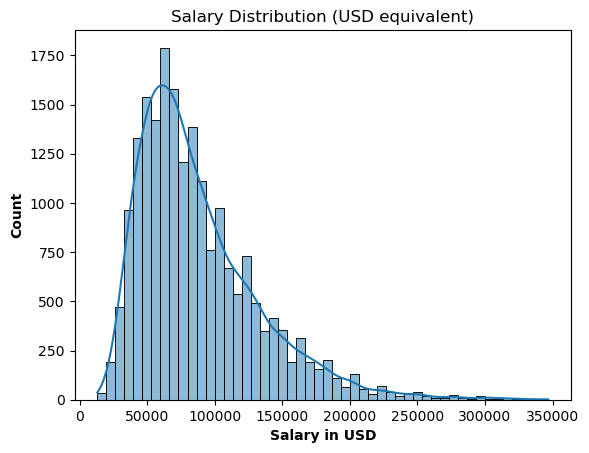

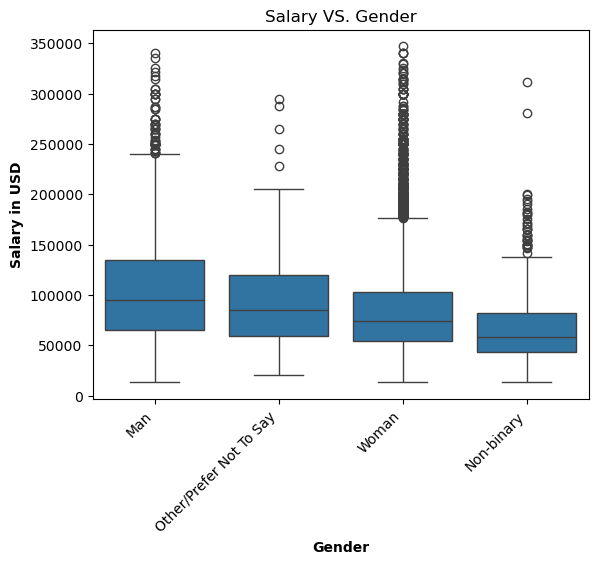

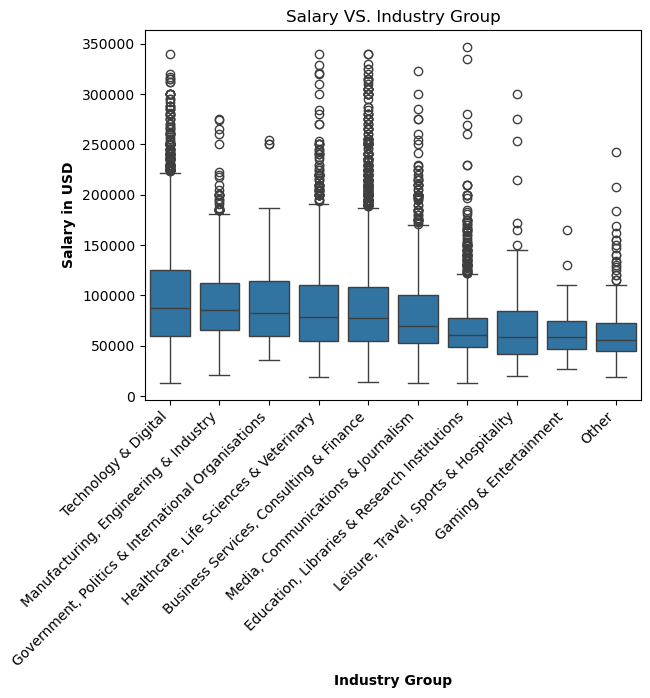

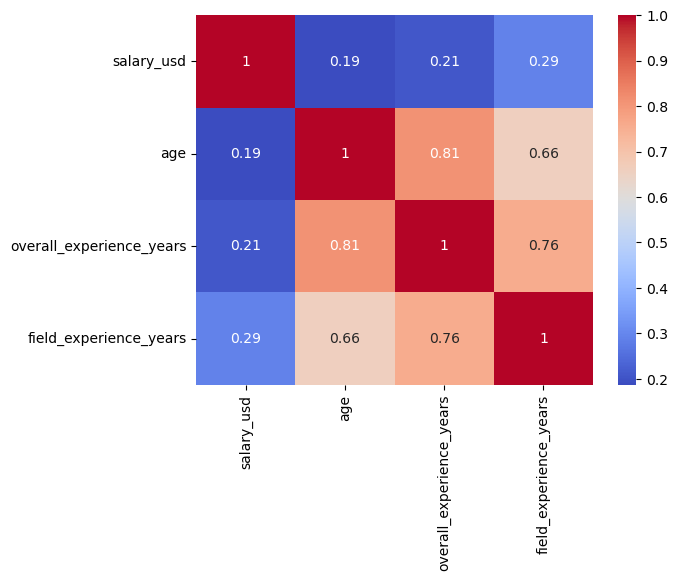

In [1091]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of salaries
sns.histplot(df_salary['salary_usd'], bins=50, kde=True)
plt.title('Salary Distribution (USD equivalent)')
plt.xlabel('Salary in USD', fontweight='bold')
plt.ylabel('Count', fontweight='bold')
plt.show()

# Salary VS. Gender
custom_order = df_salary.groupby('gender')['salary_usd'].median().sort_values(ascending=False).index
sns.boxplot(x='gender', y='salary_usd', order=custom_order, data=df_salary)
plt.title('Salary VS. Gender')
plt.xlabel('Gender', fontweight='bold')
plt.ylabel('Salary in USD', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.show()

# Salary By Industry
custom_order = df_salary.groupby('industry_grouped')['salary_usd'].median().sort_values(ascending=False).index
sns.boxplot(x='industry_grouped', y='salary_usd', order=custom_order, data=df_salary)
plt.title('Salary VS. Industry Group')
plt.xlabel('Industry Group', fontweight='bold')
plt.ylabel('Salary in USD', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.show()

# Correlation Heatmap
corr_cols = ['salary_usd', 'age', 'overall_experience_years', 'field_experience_years']
sns.heatmap(df_salary[corr_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

<h2>Feature Engineering</h2>
<ul>
    <li>Encode categories (One-Hot or Label)</li>
    <li>Create derived columns</li>
    <li>Transform skewed variables</li>
</ul>

In [1093]:
df_salary['total_income_usd'] = df_salary.apply(
    lambda x: (safe_to_float(x['annual_salary']) + safe_to_float(x['additional_compensation'])) * currency_map.get(x['currency'], 1),
    axis=1
)

# creating 'age_group' column
df_salary['age_group'] = pd.cut(df_salary['age'], bins=[18,25,35,45,60,80], labels=['18-25','25-35','35-45','45-60','60-80'])
df_salary['experience_level'] = pd.cut(df_salary['field_experience_years'], bins=[0,3,7,12,30,50], labels=['junior','mid','senior','lead','expert'])

encoded = pd.get_dummies(df_salary[['industry_grouped', 'education_level', 'gender', 'experience_level', 'age_group']], drop_first=True)

X = pd.concat([encoded, df_salary[['overall_experience_years', 'comp_usd']]], axis=1)
y = df_salary['salary_usd']

<h2>Train/Test Split & Regression Model</h2>

In [1095]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

print(f'R2: {r2_score(y_test, y_pred):.3f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}')

R2: 0.406
MAE: 25537.22
RMSE: 35056.51


<h2>Feature Importance</h2>

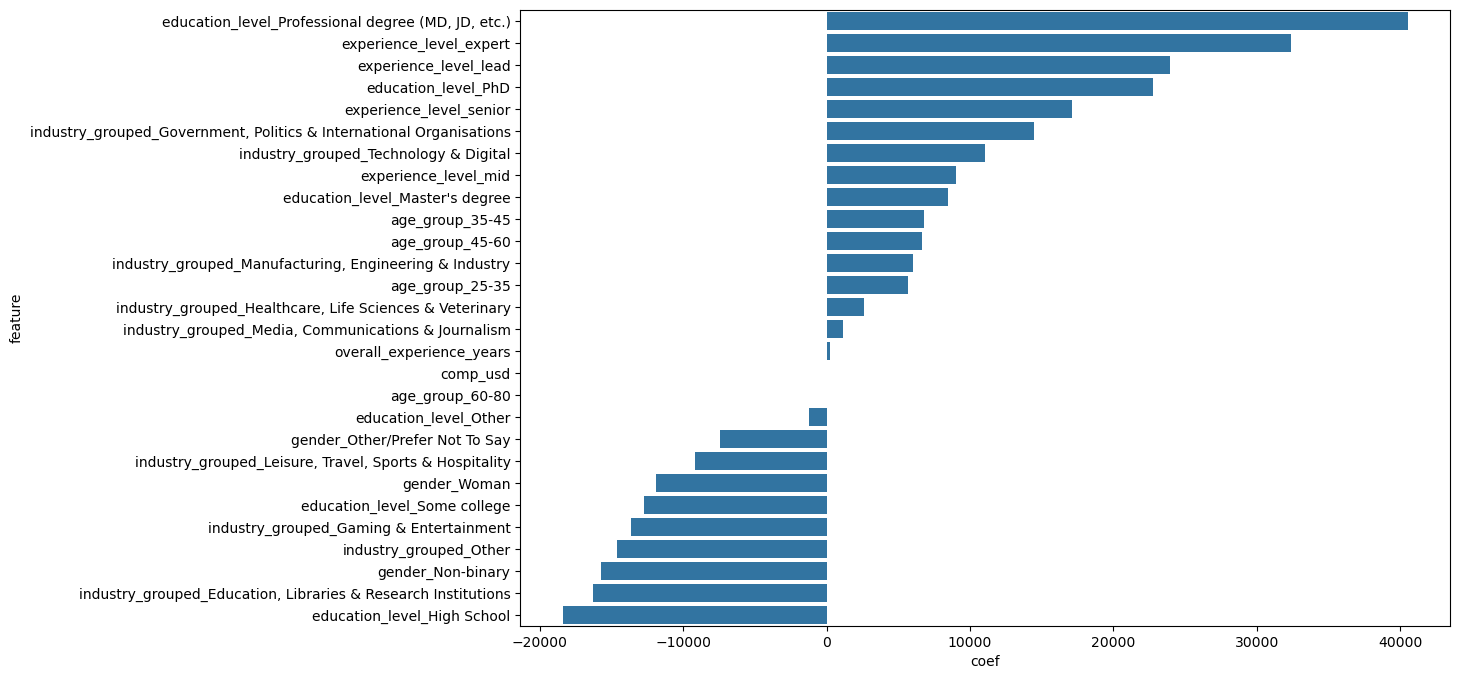

In [1097]:
coef_df = pd.DataFrame({'feature': X_train.columns, 'coef': linear_model.coef_})
coef_df = coef_df.sort_values('coef', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='coef', y='feature', data=coef_df)
plt.show()

<h4>Not good enough let's try another model</h4>

In [1099]:
df_salary.columns

Index(['timestamp', 'age', 'industry', 'job_title', 'job_title_context',
       'annual_salary', 'additional_compensation', 'currency',
       'currency_other', 'income_context', 'country', 'state', 'city',
       'overall_experience_years', 'field_experience_years', 'education_level',
       'gender', 'race', 'salary_usd', 'comp_usd', 'industry_grouped',
       'total_income_usd', 'age_group', 'experience_level'],
      dtype='object')

In [1100]:
def clean_text(city):
    if not isinstance(city, str):
        return 'Other'

    city = city.lower().strip()
    city = re.sub(r'[^a-z\s]', '', city)   # remove special characters
    city = re.sub(r'\s+', ' ', city)       # remove extra spaces

    if city in ('dc', 'washington'):
        return 'washington dc'

    if city in ('new york city', 'nyc'):
        return 'new york'
    return city

df_salary['city'] = df_salary['city'].apply(clean_text)

In [1102]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Data Preparation ---

X = df_salary.drop(columns=[
    'timestamp',
    'total_income_usd', 
    'salary_usd',     
    'annual_salary', 
    'job_title_context', 
    'currency_other', 
    'income_context'
])

# --- Log Transform Target Variable ---
# Apply log(1+x) transform to the target variable ('salary_usd').
# This is crucial for right-skewed data like salaries, as it helps normalize the distribution,
# stabilizes variance, and often leads to better model performance and more interpretable metrics (like RMSE).
# We use log1p (log(1+x)) to handle potential zero values gracefully.
y_log = np.log1p(df_salary['salary_usd']) 

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Split data into training and testing sets
# A 80/20 split is standard. random_state ensures reproducibility.
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# --- Model Training ---

# Initialize CatBoostRegressor model

cat_model = CatBoostRegressor(
    iterations=2000,              # Increased iterations for potentially better convergence
    depth=6,
    l2_leaf_reg=5,
    random_strength=1,
    learning_rate=0.03,           # Lowered learning rate, often works better with more iterations
    loss_function='RMSE',
    eval_metric='RMSE',
    bagging_temperature=1,
    early_stopping_rounds=100,    
    verbose=100,                  
    random_seed=42                
)

# Fit the model

cat_model.fit(
    X_train, y_train,
    cat_features=cat_cols,
    eval_set=(X_test, y_test),
    use_best_model=True
)

# --- Prediction and Evaluation ---

# Predict on the training and testing data (in log space)
y_train_pred_log = cat_model.predict(X_train)
y_test_pred_log = cat_model.predict(X_test)

# --- Inverse Transform Predictions ---
y_test_actual = np.expm1(y_test)
y_pred = np.expm1(y_test_pred_log)

# Also transform training predictions for consistent evaluation
y_train_actual = np.expm1(y_train) 
y_train_pred = np.expm1(y_train_pred_log)

# Calculate evaluation metrics on the ORIGINAL salary scale (USD)
mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
r2 = r2_score(y_test_actual, y_pred)

print(f'MAE (USD): {mae:,.2f}') # Formatted for better readability
print(f'RMSE (USD): {rmse:,.2f}') # Formatted for better readability
print(f"R2 Score (Test): {r2:.4f}")

# Calculate R2 for training set as well to check for overfitting
train_r2 = r2_score(y_train_actual, y_train_pred)
print(f"Train R2: {train_r2:.4f}")

# Final Test R2 (redundant print, but kept for clarity if needed)
test_r2_final = r2_score(y_test_actual, y_pred)
print(f"Test R2: {test_r2_final:.4f}")

# Optional: Calculate MAPE (Mean Absolute Percentage Error) for another perspective
# This metric is useful as it represents error as a percentage, which is intuitive for salaries.
mape = np.mean(np.abs((y_test_actual - y_pred) / y_test_actual)) * 100 if y_test_actual.mean() != 0 else 0
print(f"MAPE (%): {mape:.2f}%")


0:	learn: 0.4824121	test: 0.4833904	best: 0.4833904 (0)	total: 66.8ms	remaining: 2m 13s
100:	learn: 0.3146973	test: 0.3162905	best: 0.3162905 (100)	total: 4.1s	remaining: 1m 17s
200:	learn: 0.3023483	test: 0.3066463	best: 0.3066463 (200)	total: 8.18s	remaining: 1m 13s
300:	learn: 0.2978299	test: 0.3041478	best: 0.3041478 (300)	total: 12.3s	remaining: 1m 9s
400:	learn: 0.2942171	test: 0.3022574	best: 0.3022574 (400)	total: 16.5s	remaining: 1m 5s
500:	learn: 0.2915294	test: 0.3011612	best: 0.3011612 (500)	total: 20.6s	remaining: 1m 1s
600:	learn: 0.2891358	test: 0.3001799	best: 0.3001785 (593)	total: 24.7s	remaining: 57.6s
700:	learn: 0.2872266	test: 0.2996249	best: 0.2996249 (700)	total: 29s	remaining: 53.7s
800:	learn: 0.2854170	test: 0.2992233	best: 0.2992233 (800)	total: 33.2s	remaining: 49.7s
900:	learn: 0.2836261	test: 0.2987004	best: 0.2987004 (900)	total: 37.5s	remaining: 45.7s
1000:	learn: 0.2820539	test: 0.2983354	best: 0.2983354 (1000)	total: 41.7s	remaining: 41.6s
1100:	learn